# AMLDL Assignment 2 - Predicting Crime Against Women in India

## 1. Objective

The objective of this assignment is to predict future crime counts against women for Indian States and Union Territories using historical NCRB crime data.

The previous three years of crime counts are used as input features to predict the crime count of the following year.

## 2. Modelling Approach

The project follows a rolling three-year prediction approach.

The following regression models are evaluated:

- Linear Regression
- Polynomial Regression
- Random Forest Regression
- Gradient Boosting Regression

Model performance is evaluated using MAE, MSE, RMSE and R² techniques.

Hyperparameter tuning and 5-Fold Cross-Validation are also performed to compare model performance and select the most suitable model.

## 3. Dataset Overview

The project uses multiple cleaned NCRB datasets covering consecutive three-year periods.

Each dataset contains crime counts for all Indian States and Union Territories. The datasets overlap by one or more years so that a continuous historical series can be constructed.

In [1]:
# Need to execute this cell only for the first time

#%pip install scikit-learn
#%pip install matplotlib

In [2]:
import pandas as pd
import os

files = os.listdir('Data/')

# List of all input dataset
for file in files:
    print(file)

State-UT-wise Crime against Women (IPC + SLL) - 2015-2017.csv
State-UT-wise Crime against Women (IPC + SLL) - 2016-2018.csv
State-UT-wise Crime against Women (IPC + SLL) - 2017-2019.csv
State-UT-wise Crime against Women (IPC + SLL) - 2018-2020.csv
State-UT-wise Crime against Women (IPC + SLL) - 2019-2021.csv
State-UT-wise Crime against Women (IPC + SLL) - 2020-2022.csv
State-UT-wise Crime against Women (IPC + SLL) - 2021-2023.csv


### **Example Dataset**


In [3]:
df = pd.read_csv('Data/State-UT-wise Crime against Women (IPC + SLL) - 2015-2017.csv')

df.head()

,Category,State/UT,2015,2016,2017
0,State,Andhra Pradesh,15967,16362,17909
1,State,Arunachal Pradesh,384,367,337
2,State,Assam,23365,20869,23082
3,State,Bihar,13904,13400,14711
4,State,Chhattisgarh,5783,5947,7996


### **Schema/structural validation for the input dataset**
**Expectations**:
1. All dataset file must have 5 columns.
   - State/UT Name.
   - Category i.e. State or Union Territory.
   - 3 year columns (e.g. 2015, 2016 & 2017)
3. All dataset file must have 36 rows i.e. 1 row for each Indian State & UT.

In [4]:
import glob

csv_files = [
    file for file in glob.glob('Data/*.csv')
    if 'predictions' not in file
]

for file in sorted(csv_files):
    temp_df = pd.read_csv(file)

    print("=" * 80)
    print("File:", file.split('/')[-1])
    print("Rows:", temp_df.shape[0])
    print("Columns:", temp_df.shape[1])
    print("Column names:", temp_df.columns.tolist())
    print("Data types:")

File: Data\State-UT-wise Crime against Women (IPC + SLL) - 2015-2017.csv
Rows: 36
Columns: 5
Column names: ['Category', 'State/UT', '2015', '2016', '2017']
Data types:
File: Data\State-UT-wise Crime against Women (IPC + SLL) - 2016-2018.csv
Rows: 36
Columns: 5
Column names: ['Category', 'State/UT', '2016', '2017', '2018']
Data types:
File: Data\State-UT-wise Crime against Women (IPC + SLL) - 2017-2019.csv
Rows: 36
Columns: 5
Column names: ['Category', 'State/UT', '2017', '2018', '2019']
Data types:
File: Data\State-UT-wise Crime against Women (IPC + SLL) - 2018-2020.csv
Rows: 36
Columns: 5
Column names: ['Category', 'State/UT', '2018', '2019', '2020']
Data types:
File: Data\State-UT-wise Crime against Women (IPC + SLL) - 2019-2021.csv
Rows: 36
Columns: 5
Column names: ['State/UT', '2019', '2020', '2021', 'Category']
Data types:
File: Data\State-UT-wise Crime against Women (IPC + SLL) - 2020-2022.csv
Rows: 36
Columns: 5
Column names: ['State/UT', '2020', '2021', '2022', 'Category']
Data

### **Data Loading & Initial Corrections**
1. The loaded datasets are combined to create a continuous historical dataset covering **2015–2023**.
2. Since all the dataset files have counts for 3 year in a rollover pattern, we essentially remove the colmuns that are duplicate.
   - As part of this, we also do a data integrity check to ensure the counts for a State/UT is same for a year across all the dataset file (if present).
   - For example, the count for the year 2017 appears in the following 3 files. So, the count for any State/UT for 2017 must remain same in all the 3 files:
     - State-UT-wise Crime against Women (IPC + SLL) - 2015-2017.csv
     - State-UT-wise Crime against Women (IPC + SLL) - 2016-2018.csv
     - State-UT-wise Crime against Women (IPC + SLL) - 2017-2019.csv
   - For any count that appears different, the count that has appeared more number of times is considered to be the final count.
3. The final dataframe will have records for all 36 State/UTs wherein each record have the count for all the years i.e. 2015 - 2023.

In [5]:
# Read all CSV files into a list

dataframes = []

for file in sorted(csv_files):
    temp_df = pd.read_csv(file)
    dataframes.append(temp_df)

print("Number of files loaded:", len(dataframes))

Number of files loaded: 7


In [6]:
# Create one table containing State/UT and all available years

combined = dataframes[0][['State/UT', 'Category', '2015', '2016', '2017']].copy()

for df_temp in dataframes[1:]:
    year_columns = [col for col in df_temp.columns if col.isdigit()]

    columns_to_add = ['State/UT'] + year_columns

    combined = combined.merge(
        df_temp[columns_to_add],
        on='State/UT',
        how='left',
        suffixes=('', '_duplicate')
    )

print("Rows:", combined.shape[0])
print("Columns:", combined.columns.tolist())

Rows: 36
Columns: ['State/UT', 'Category', '2015', '2016', '2017', '2016_duplicate', '2017_duplicate', '2018', '2017_duplicate', '2018_duplicate', '2019', '2018_duplicate', '2019_duplicate', '2020', '2019_duplicate', '2020_duplicate', '2021', '2020_duplicate', '2021_duplicate', '2022', '2021_duplicate', '2022_duplicate', '2023']


In [7]:
# Check whether overlapping year values are identical

for year in range(2016, 2023):
    year_columns = [
        col for col in combined.columns
        if col == str(year) or col.startswith(str(year) + '_duplicate')
    ]

    print(f"\n{year}: {year_columns}")

    if len(year_columns) > 1:
        comparison = combined[year_columns].nunique(axis=1)

        differences = combined[comparison > 1]

        print("Rows with differences:", len(differences))

        if len(differences) > 0:
            print(differences[['State/UT'] + year_columns].to_string(index=False))


2016: ['2016', '2016_duplicate']
Rows with differences: 0

2017: ['2017', '2017_duplicate', '2017_duplicate']
Rows with differences: 0

2018: ['2018', '2018_duplicate', '2018_duplicate']
Rows with differences: 1
State/UT  2018  2018_duplicate  2018_duplicate  2018_duplicate  2018_duplicate
   Assam 27728           27687           27687           27687           27687

2019: ['2019', '2019_duplicate', '2019_duplicate']
Rows with differences: 1
   State/UT  2019  2019_duplicate  2019_duplicate  2019_duplicate  2019_duplicate
West Bengal 30394           29859           29859           29859           29859

2020: ['2020', '2020_duplicate', '2020_duplicate']
Rows with differences: 0

2021: ['2021', '2021_duplicate', '2021_duplicate']
Rows with differences: 0

2022: ['2022', '2022_duplicate']
Rows with differences: 0


#### **Discrepancies Found**
| Sl. No. | State/UT    | Year | 1st Count | 2nd Count | 3rd Count |
| ------- | ----------- | ---- | --------- | --------- | --------- |
| 1       | Assam       | 2018 | 27728     | 27687     | 27687     |
| 2       | West Bengal | 2019 | 30394     | 29859     | 29859     |


In [8]:
# Resolve overlapping years using the value that occurs most often.

cleaned_data = pd.DataFrame()

cleaned_data['State/UT'] = combined['State/UT']
cleaned_data['Category'] = combined['Category']

for year in range(2015, 2024):
    year_columns = [
        col for col in combined.columns
        if col == str(year) or col.startswith(str(year) + '_duplicate')
    ]

    # If the year appears in multiple files, use the value
    # occurring most frequently for each State/UT.
    cleaned_data[str(year)] = combined[year_columns].mode(axis=1)[0]

print("Rows:", cleaned_data.shape[0])
print("Columns:", cleaned_data.shape[1])
print("\nColumns:")
print(cleaned_data.columns.tolist())

print("\nAssam 2018:",
      cleaned_data.loc[cleaned_data['State/UT'] == 'Assam', '2018'].iloc[0])

print("West Bengal 2019:",
      cleaned_data.loc[cleaned_data['State/UT'] == 'West Bengal', '2019'].iloc[0])
cleaned_data.head(10)

Rows: 36
Columns: 11

Columns:
['State/UT', 'Category', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

Assam 2018: 27687
West Bengal 2019: 29859


,State/UT,Category,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Andhra Pradesh,State,15967,16362,17909,16438,17746,17089,17752,25503,22418
1,Arunachal Pradesh,State,384,367,337,368,317,281,366,335,326
2,Assam,State,23365,20869,23082,27687,30025,26352,29046,14148,12070
3,Bihar,State,13904,13400,14711,16920,18587,15359,17950,20222,22952
4,Chhattisgarh,State,5783,5947,7996,8587,7689,7385,7344,8693,8035
5,Goa,State,392,371,369,362,329,219,224,273,286
6,Gujarat,State,7777,8532,8133,8329,8799,8028,7348,7731,7805
7,Haryana,State,9511,9839,11370,14326,14683,13000,16658,16743,15758
8,Himachal Pradesh,State,1295,1222,1246,1633,1636,1614,1599,1551,1604
9,Jammu & Kashmir,Union Territory,3366,2850,3129,3437,3069,3405,3937,3716,3653


### Training Data vs Validation Data
1. The consolidated dataset contains crime counts from 2015 to 2023 for 36 States/UTs.
2. A 3-year rolling window is used to convert the historical data into supervised-learning examples.
3. This produces 216 input-target examples, covering target years 2018 to 2023.
4. The examples are divided chronologically to avoid using future observations to predict the past.
5. **Training Data**: Target years 2018–2021 → 144 examples. Used to train the models.
6. **Test Data**: Target years 2022–2023 → 72 examples. Used to evaluate model performance.

In [9]:
examples = []

for _, row in cleaned_data.iterrows():
    for start_year in range(2015, 2021):

        examples.append({
            'State/UT': row['State/UT'],
            'Year_1': row[str(start_year)],
            'Year_2': row[str(start_year + 1)],
            'Year_3': row[str(start_year + 2)],
            'Target_Value': row[str(start_year + 3)],
            'Target_Year': start_year + 3
        })

examples_df = pd.DataFrame(examples)

print("Total examples:", len(examples_df))
print("Columns:", examples_df.columns.tolist())
examples_df.head(40)

Total examples: 216
Columns: ['State/UT', 'Year_1', 'Year_2', 'Year_3', 'Target_Value', 'Target_Year']


,State/UT,Year_1,Year_2,Year_3,Target_Value,Target_Year
0,Andhra Pradesh,15967,16362,17909,16438,2018
1,Andhra Pradesh,16362,17909,16438,17746,2019
2,Andhra Pradesh,17909,16438,17746,17089,2020
3,Andhra Pradesh,16438,17746,17089,17752,2021
4,Andhra Pradesh,17746,17089,17752,25503,2022
5,Andhra Pradesh,17089,17752,25503,22418,2023
6,Arunachal Pradesh,384,367,337,368,2018
7,Arunachal Pradesh,367,337,368,317,2019
8,Arunachal Pradesh,337,368,317,281,2020
9,Arunachal Pradesh,368,317,281,366,2021


In [10]:
# Split the 216 historical examples into training and validation data

training_data = examples_df[
    examples_df['Target_Year'].between(2018, 2021)
].copy()

validation_data = examples_df[
    examples_df['Target_Year'].between(2022, 2023)
].copy()

print("Training examples:", len(training_data))
print("Testing examples:", len(validation_data))

Training examples: 144
Testing examples: 72


## 4. Model Training & Performance Evaluation
1. The prepared dataset is used to train and evaluate multiple regression models.
2. **Linear Regression** is used as the baseline model because it provides a simple and interpretable relationship between the input features and the target.
3. **Polynomial Regression** is then evaluated to check whether a non-linear relationship can improve the predictions.
4. **Random Forest Regression** and **Gradient Boosting Regression** are subsequently evaluated as ensemble-based approaches.
5. The models are evaluated on the unseen test data using MAE, MSE, RMSE and R² techniques.
6. The model performances are compared to identify which approach provides better predictive results.

### Linear Regression

- Linear Regression is used as the baseline model for predicting the target crime count from the previous three years' crime counts.
- It assumes a linear relationship between the input features and the target value.
- Its simple structure makes the model easy to interpret and provides a reference point for comparing more complex models.

In [11]:
X_train = training_data[['Year_1', 'Year_2', 'Year_3']]
y_train = training_data['Target_Value']

X_test = validation_data[['Year_1', 'Year_2', 'Year_3']]
y_test = validation_data['Target_Value']

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

# Model training using linear regression
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.04,0.38,0.61]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Year_1','Year_2','Year_3']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,210
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [12]:
import numpy as np

# Predicting using the trained model for the validation dataset
y_pred_linear = np.round(linear_model.predict(X_test), 2)

print(y_pred_linear[:10])

[18354.52 23310.98   554.67   566.91 29321.37 21112.23 17845.85 20092.14
  7852.17  8646.74]


In [13]:
# Comparing predicted values with actuals
comparison = validation_data[['State/UT', 'Target_Year', 'Target_Value']].copy()

comparison['Predicted'] = y_pred_linear

comparison.head(10)

,State/UT,Target_Year,Target_Value,Predicted
4,Andhra Pradesh,2022,25503,18354.52
5,Andhra Pradesh,2023,22418,23310.98
10,Arunachal Pradesh,2022,335,554.67
11,Arunachal Pradesh,2023,326,566.91
16,Assam,2022,14148,29321.37
17,Assam,2023,12070,21112.23
22,Bihar,2022,20222,17845.85
23,Bihar,2023,22952,20092.14
28,Chhattisgarh,2022,8693,7852.17
29,Chhattisgarh,2023,8035,8646.74


In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_linear = np.round(mean_squared_error(y_test, y_pred_linear), 2)
mae_linear = np.round(mean_absolute_error(y_test, y_pred_linear), 2)
rmse_linear = np.round((mean_squared_error(y_test, y_pred_linear) ** 0.5), 2)
r2_linear = np.round(r2_score(y_test, y_pred_linear), 2)

print("Linear Regression - Test Results")
print("MSE :", mse_linear)
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression - Test Results
MSE : 9360029.29
MAE: 1585.99
RMSE: 3059.42
R²  : 0.96


In [15]:
comparison['Absolute_Error'] = abs(
    comparison['Target_Value'] - comparison['Predicted']
)

comparison['Percentage_Error'] = np.round(((
    comparison['Absolute_Error'] / comparison['Target_Value']
) * 100), 2)

comparison.head(10)

,State/UT,Target_Year,Target_Value,Predicted,Absolute_Error,Percentage_Error
4,Andhra Pradesh,2022,25503,18354.52,7148.48,28.03
5,Andhra Pradesh,2023,22418,23310.98,892.98,3.98
10,Arunachal Pradesh,2022,335,554.67,219.67,65.57
11,Arunachal Pradesh,2023,326,566.91,240.91,73.90
16,Assam,2022,14148,29321.37,15173.37,107.25
17,Assam,2023,12070,21112.23,9042.23,74.91
22,Bihar,2022,20222,17845.85,2376.15,11.75
23,Bihar,2023,22952,20092.14,2859.86,12.46
28,Chhattisgarh,2022,8693,7852.17,840.83,9.67
29,Chhattisgarh,2023,8035,8646.74,611.74,7.61


### Polynomial Regression
1. Polynomial Regression extends Linear Regression by introducing polynomial terms into the input features.
2. It is evaluated to determine whether a non-linear relationship between historical crime counts and the target can improve prediction.
3. A degree-2 polynomial model is initially used to capture possible curvature while keeping the model relatively simple.

In [16]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

from sklearn.linear_model import LinearRegression

poly_model = LinearRegression()

# Model training using polynomial regression
poly_model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[0. ,0.37,0.39,...,0. ,0. ,0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-134.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1.64e+10,2.15e+09,9.00e+08,...,7.29e+03,3.14e+03,0.00e+00]"


In [17]:
# Predicting using the trained model for the validation dataset
y_pred_poly = np.round(poly_model.predict(X_test_poly), 2)

print(y_pred_poly[:10])

[19250.92 22969.32   234.23   242.12 32222.83 24572.67 20073.71 19854.43
  8299.38  8696.97]


In [18]:
# Comparing predicted values with actuals
poly_comparison = validation_data[['State/UT', 'Target_Year', 'Target_Value']].copy()

poly_comparison['Predicted'] = y_pred_poly

poly_comparison['Absolute_Error'] = abs(
    poly_comparison['Target_Value'] - poly_comparison['Predicted']
)

poly_comparison['Percentage_Error'] = np.round(((
    poly_comparison['Absolute_Error'] / poly_comparison['Target_Value']
) * 100), 2)

poly_comparison.head(10)

,State/UT,Target_Year,Target_Value,Predicted,Absolute_Error,Percentage_Error
4,Andhra Pradesh,2022,25503,19250.92,6252.08,24.52
5,Andhra Pradesh,2023,22418,22969.32,551.32,2.46
10,Arunachal Pradesh,2022,335,234.23,100.77,30.08
11,Arunachal Pradesh,2023,326,242.12,83.88,25.73
16,Assam,2022,14148,32222.83,18074.83,127.76
17,Assam,2023,12070,24572.67,12502.67,103.58
22,Bihar,2022,20222,20073.71,148.29,0.73
23,Bihar,2023,22952,19854.43,3097.57,13.50
28,Chhattisgarh,2022,8693,8299.38,393.62,4.53
29,Chhattisgarh,2023,8035,8696.97,661.97,8.24


In [19]:
mae_poly = np.round(mean_absolute_error(y_test, y_pred_poly), 2)
mse_poly = np.round(mean_squared_error(y_test, y_pred_poly), 2)
rmse_poly = np.round((mse_poly ** 0.5), 2)
r2_poly = np.round(r2_score(y_test, y_pred_poly), 2)

print("Polynomial Regression - Test Results")
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)
print("R²  :", r2_poly)

Polynomial Regression - Test Results
MAE : 1420.22
MSE : 9693354.28
RMSE: 3113.42
R²  : 0.96


## Polynomial Regression — Hyperparameter Tuning

- The polynomial regression model is tuned to identify the most suitable polynomial degree.
- Polynomial degrees 1 to 4 are evaluated with RMSE used as the selection metric.
- The cross-validation results are compared to identify the degree with the best validation performance.
- Finally, the tuned model's performance on the test data is evaluated using **MAE, MSE, RMSE and R²**.

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('model', LinearRegression())
])

param_grid = {
    'poly__degree': [1, 2, 3, 4]
}

grid_search = GridSearchCV(
    poly_pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

In [21]:
grid_search.fit(X_train, y_train)

print("Best Polynomial Degree:", grid_search.best_params_['poly__degree'])
print("Best Cross-Validation RMSE:", np.round(-grid_search.best_score_, 2))

Best Polynomial Degree: 1
Best Cross-Validation RMSE: 2321.91


In [22]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_summary = cv_results[
    ['param_poly__degree', 'mean_test_score', 'std_test_score']
].copy()

cv_summary['RMSE'] = -cv_summary['mean_test_score']

cv_summary.sort_values('RMSE')

,param_poly__degree,mean_test_score,std_test_score,RMSE
0,1,-2321.906715,1143.394102,2321.906715
1,2,-3534.925306,2597.804086,3534.925306
2,3,-19605.050940,28934.482330,19605.050940
3,4,-93155.431603,113626.441031,93155.431603


In [23]:
best_model = grid_search.best_estimator_

y_pred_tuned = np.round(best_model.predict(X_test), 2)

print(y_pred_tuned[:10])

[18354.52 23310.98   554.67   566.91 29321.37 21112.23 17845.85 20092.14
  7852.17  8646.74]


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_tuned = np.round(mean_absolute_error(y_test, y_pred_tuned), 2)
mse_tuned = np.round(mean_squared_error(y_test, y_pred_tuned), 2)
rmse_tuned = np.round(np.sqrt(mse_tuned), 2)
r2_tuned = np.round(r2_score(y_test, y_pred_tuned), 2)

print("Tuned Model - Test Results")
print("MAE :", mae_tuned)
print("MSE :", mse_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)

Tuned Model - Test Results
MAE : 1585.99
MSE : 9360029.29
RMSE: 3059.42
R²  : 0.96


In [25]:
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression (Degree 2)',
        'Tuned Polynomial Regression'
    ],
    'MAE': [
        mae_linear,
        mae_poly,
        mae_tuned
    ],
    'MSE': [
        mse_linear,
        mse_poly,
        mse_tuned
    ],
    'RMSE': [
        rmse_linear,
        rmse_poly,
        rmse_tuned
    ],
    'R²': [
        r2_linear,
        r2_poly,
        r2_tuned
    ]
})

model_comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,1585.99,9360029.29,3059.42,0.96
1,Polynomial Regression (Degree 2),1420.22,9693354.28,3113.42,0.96
2,Tuned Polynomial Regression,1585.99,9360029.29,3059.42,0.96


## Random Forest — Hyperparameter Tuning

- Random Forest Regression is tuned to identify a combination of parameters that provides better predictive performance.
- Grid Search is used to evaluate different combinations of the number of trees, maximum tree depth and minimum samples required for splitting.
- The best parameter combination is selected based on the lowest cross-validation RMSE.
- The selected Random Forest model is then used for prediction on the unseen test data.

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

In [27]:
rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("Best Cross-Validation RMSE:")
print(-rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation RMSE:
3094.1868577657997


In [28]:
best_rf = rf_grid.best_estimator_

y_pred_rf = np.round(best_rf.predict(X_test), 2)

mae_rf = np.round(mean_absolute_error(y_test, y_pred_rf), 2)
mse_rf = np.round(mean_squared_error(y_test, y_pred_rf), 2)
rmse_rf = np.round(np.sqrt(mse_rf), 2)
r2_rf = np.round(r2_score(y_test, y_pred_rf), 2)

print("Random Forest - Test Results")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest - Test Results
MAE : 1844.21
MSE : 14421374.4
RMSE: 3797.55
R²  : 0.94


## Model Performance Comparison

- The test-set performance of the regression models evaluated so far is consolidated into a single comparison table.
- **MAE, MSE and RMSE** are used to measure prediction error, where lower values indicate better performance.
- **R²** measures how well the model explains the variation in the target variable, where a higher value indicates better performance.
- The models are compared using the same test dataset to ensure a fair comparison.
- RMSE is used as the primary basis for ranking the models because it gives greater importance to larger prediction errors.

In [29]:
final_model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression (Degree 2)',
        'Tuned Polynomial Regression',
        'Random Forest Regression'
    ],
    'MAE': [
        mae_linear,
        mae_poly,
        mae_tuned,
        mae_rf
    ],
    'MSE': [
        mse_linear,
        mse_poly,
        mse_tuned,
        mse_rf
    ],
    'RMSE': [
        rmse_linear,
        rmse_poly,
        rmse_tuned,
        rmse_rf
    ],
    'R²': [
        r2_linear,
        r2_poly,
        r2_tuned,
        r2_rf
    ]
})

final_model_comparison.sort_values('RMSE')

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,1585.99,9360029.29,3059.42,0.96
2,Tuned Polynomial Regression,1585.99,9360029.29,3059.42,0.96
1,Polynomial Regression (Degree 2),1420.22,9693354.28,3113.42,0.96
3,Random Forest Regression,1844.21,14421374.40,3797.55,0.94


In [30]:
final_poly = PolynomialFeatures(degree=2)

X_all = examples_df[['Year_1', 'Year_2', 'Year_3']]
y_all = examples_df['Target_Value']

X_all_poly = final_poly.fit_transform(X_all)

final_model = LinearRegression()
final_model.fit(X_all_poly, y_all)

print("Final model trained on:", len(X_all), "examples")

Final model trained on: 216 examples


In [31]:
prediction_2024 = cleaned_data[
    ['State/UT', '2021', '2022', '2023']
].copy()

prediction_2024.columns = [
    'State/UT', 'Year_1', 'Year_2', 'Year_3'
]

prediction_2024['Target_Year'] = 2024

prediction_2024.head()

,State/UT,Year_1,Year_2,Year_3,Target_Year
0,Andhra Pradesh,17752,25503,22418,2024
1,Arunachal Pradesh,366,335,326,2024
2,Assam,29046,14148,12070,2024
3,Bihar,17950,20222,22952,2024
4,Chhattisgarh,7344,8693,8035,2024


In [32]:
X_2024 = prediction_2024[['Year_1', 'Year_2', 'Year_3']]

X_2024_poly = final_poly.transform(X_2024)

prediction_2024['Predicted_2024'] = np.round(final_model.predict(X_2024_poly))

prediction_2024.head(10)

,State/UT,Year_1,Year_2,Year_3,Target_Year,Predicted_2024
0,Andhra Pradesh,17752,25503,22418,2024,24624.0
1,Arunachal Pradesh,366,335,326,2024,351.0
2,Assam,29046,14148,12070,2024,35823.0
3,Bihar,17950,20222,22952,2024,22520.0
4,Chhattisgarh,7344,8693,8035,2024,8745.0
5,Goa,224,273,286,2024,262.0
6,Gujarat,7348,7731,7805,2024,8344.0
7,Haryana,16658,16743,15758,2024,17514.0
8,Himachal Pradesh,1599,1551,1604,2024,1729.0
9,Jammu & Kashmir,3937,3716,3653,2024,4136.0


In [33]:
prediction_2024.to_csv(
    'Output/AMLDL_A2_2024_predictions.csv',
    index=False
)

print("2024 predictions saved successfully.")

2024 predictions saved successfully.


In [34]:
prediction_2024[
    ['State/UT', 'Year_1', 'Year_2', 'Year_3', 'Predicted_2024']
].sort_values('State/UT')

,State/UT,Year_1,Year_2,Year_3,Predicted_2024
29,Andaman and Nicobar Islands,169,178,205,176.0
0,Andhra Pradesh,17752,25503,22418,24624.0
1,Arunachal Pradesh,366,335,326,351.0
2,Assam,29046,14148,12070,35823.0
3,Bihar,17950,20222,22952,22520.0
30,Chandigarh,343,325,371,356.0
4,Chhattisgarh,7344,8693,8035,8745.0
34,Dadra & Nagar Haveli and Daman & Diu,99,126,124,100.0
31,Delhi,14277,14247,13439,15044.0
5,Goa,224,273,286,262.0


## Feature Importance Analysis

- The three historical crime-count features are evaluated to understand their individual relationship with the target variable.
- The `f_regression` method calculates an **F-score** and **P-value** for each feature.
- A higher F-score indicates a stronger relationship between the feature and the target.
- The P-value indicates whether the observed relationship is statistically significant.
- The results are sorted by F-score to identify which historical year has the strongest individual relationship with the target.

In [35]:
from sklearn.feature_selection import f_regression

X_features = training_data[['Year_1', 'Year_2', 'Year_3']]
y_features = training_data['Target_Value']

scores, p_values = f_regression(X_features, y_features)

feature_selection = pd.DataFrame({
    'Feature': X_features.columns,
    'F_Score': scores,
    'P_Value': p_values
}).sort_values('F_Score', ascending=False)

feature_selection

,Feature,F_Score,P_Value
2,Year_3,4589.657716,5.224939e-110
1,Year_2,3939.698146,1.885304e-105
0,Year_1,2497.381627,5.280629e-92


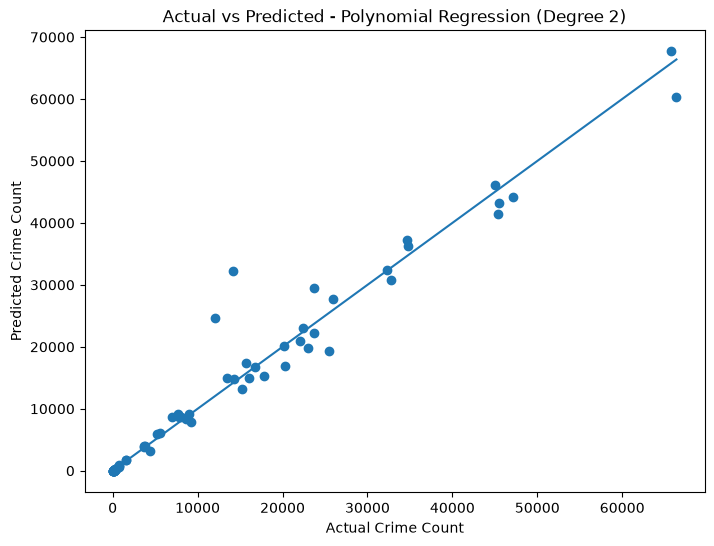

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_poly)

plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Actual vs Predicted - Polynomial Regression (Degree 2)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

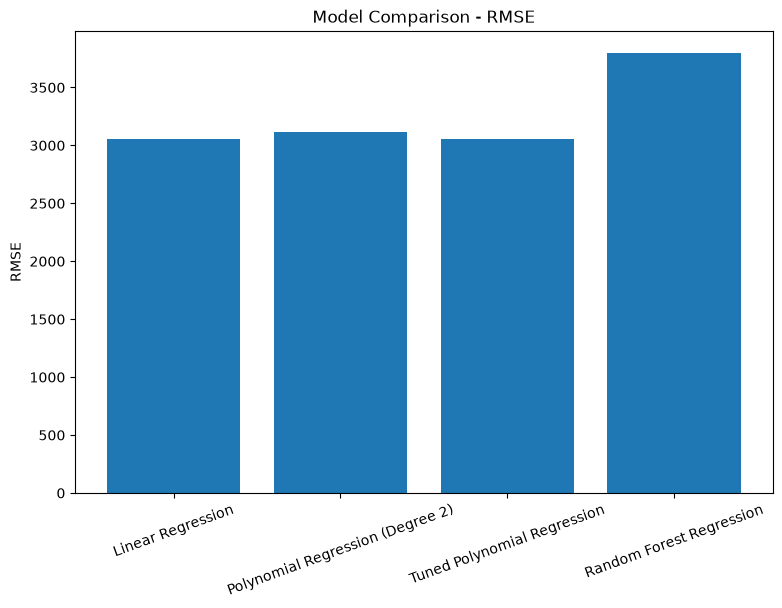

In [37]:
plt.figure(figsize=(9, 6))

plt.bar(
    final_model_comparison['Model'],
    final_model_comparison['RMSE']
)

plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")
plt.xticks(rotation=20)
plt.show()

## K-Fold Cross-Validation

- K-Fold Cross-Validation is used to assess how consistently the model performs across different subsets of the training data.
- The training data is divided into **5 folds**.
- In each iteration, four folds are used for training and the remaining fold is used for validation.
- This process is repeated until each fold has been used once for validation.
- RMSE is calculated for each fold, followed by the **mean RMSE and standard deviation** to summarize the model's overall performance and consistency.
- A Polynomial Regression model with **degree 2** is evaluated using this approach.

In [38]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

poly2_pipeline = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

In [39]:
cv_rmse_scores = np.round(-cross_val_score(
    poly2_pipeline,
    X_train,
    y_train,
    cv=kfold,
    scoring='neg_root_mean_squared_error'
), 2)

print("RMSE for each fold:")
print(cv_rmse_scores)

print("\nMean RMSE:", cv_rmse_scores.mean())
print("Standard Deviation:", cv_rmse_scores.std())

RMSE for each fold:
[1596.03 8983.87 2629.36 8430.3  4348.17]

Mean RMSE: 5197.546
Standard Deviation: 3002.4951049325628


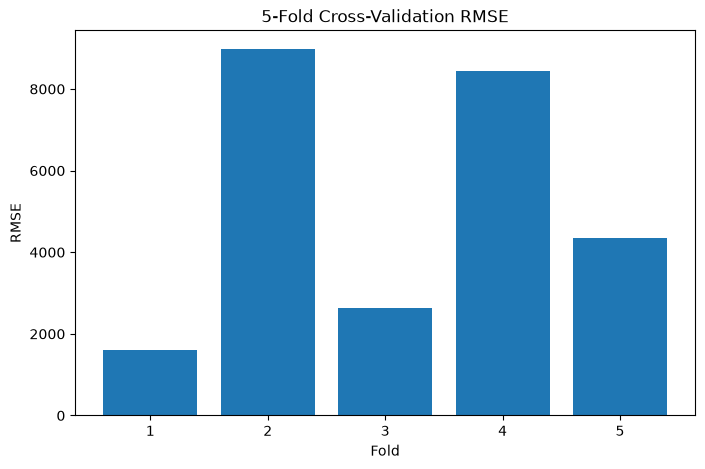

In [40]:
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, 6),
    cv_rmse_scores
)

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("5-Fold Cross-Validation RMSE")

plt.show()

In [41]:
cv_summary_kfold = pd.DataFrame({
    'Fold': range(1, 6),
    'RMSE': cv_rmse_scores
})

cv_summary_kfold.loc[len(cv_summary_kfold)] = [
    'Mean',
    cv_rmse_scores.mean()
]

cv_summary_kfold

,Fold,RMSE
0,1,1596.030
1,2,8983.870
2,3,2629.360
3,4,8430.300
4,5,4348.170
5,Mean,5197.546


## Gradient Boosting Regression

- Gradient Boosting Regression is used as another ensemble-based regression approach for comparison.
- The model builds multiple decision trees sequentially, where each new tree focuses on reducing the errors made by the previous trees.
- The model is trained using the training data and then used to predict crime counts for the unseen test data.
- The predictions are evaluated using **MAE, MSE, RMSE and R²**.
- The performance is compared with the earlier regression models to determine whether Gradient Boosting provides an improvement.

In [42]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = np.round(gb_model.predict(X_test), 2)

print(y_pred_gb[:10])

[17024.61 22319.65   431.66   448.36 33696.75 21386.55 17024.61 22030.38
  7990.25  8060.63]


In [43]:
mae_gb = np.round(mean_absolute_error(y_test, y_pred_gb), 2)
mse_gb = np.round(mean_squared_error(y_test, y_pred_gb), 2)
rmse_gb = np.round(np.sqrt(mse_gb), 2)
r2_gb = np.round(r2_score(y_test, y_pred_gb), 2)

print("Gradient Boosting - Test Results")
print("MAE :", mae_gb)
print("MSE :", mse_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting - Test Results
MAE : 1769.51
MSE : 14446548.08
RMSE: 3800.86
R²  : 0.94


In [44]:
final_model_comparison.loc[len(final_model_comparison)] = {
    'Model': 'Gradient Boosting',
    'MAE': mae_gb,
    'MSE': mse_gb,
    'RMSE': rmse_gb,
    'R²': r2_gb
}

final_model_comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,1585.99,9360029.29,3059.42,0.96
1,Polynomial Regression (Degree 2),1420.22,9693354.28,3113.42,0.96
2,Tuned Polynomial Regression,1585.99,9360029.29,3059.42,0.96
3,Random Forest Regression,1844.21,14421374.40,3797.55,0.94
4,Gradient Boosting,1769.51,14446548.08,3800.86,0.94
